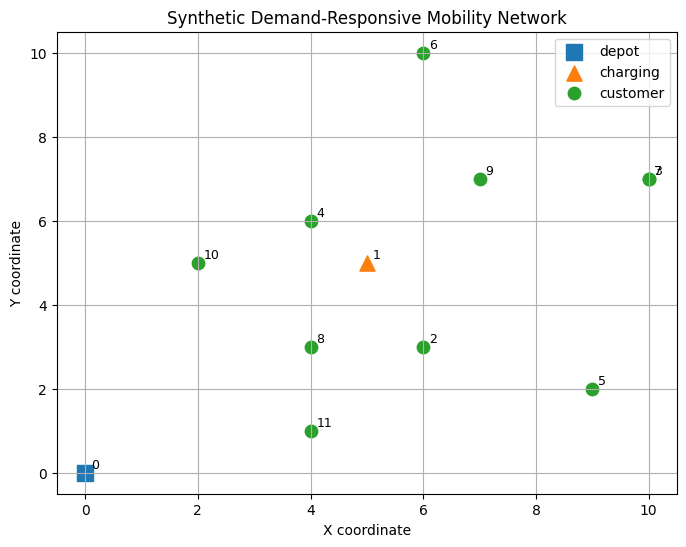

Battery capacity: 25.0
Energy per unit distance: 1.0
Baseline route (reindexed): [0, 10, 7, 1, 4, 6, 2, 8, 5, 3, 9, 0]
Baseline route (original node IDs): [0, 11, 8, 2, 5, 7, 3, 9, 6, 4, 10, 0]


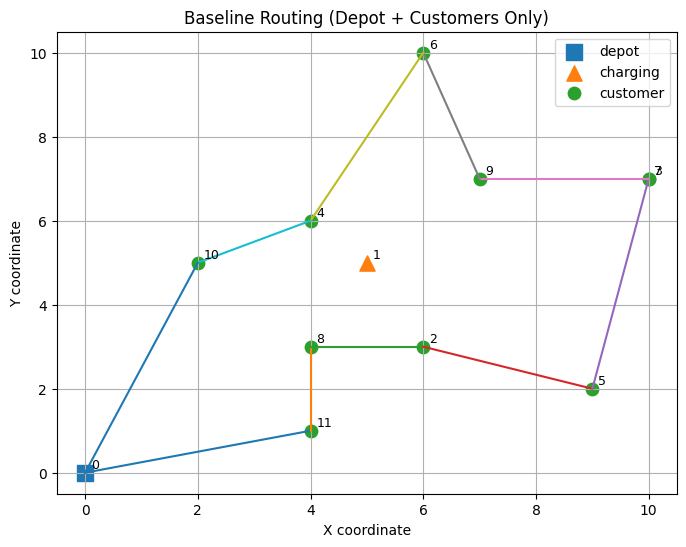

Battery depleted between 6 -> 4
Baseline EV-feasible route: False
Baseline battery levels: [25.0, np.float64(20.87689437438234), np.float64(18.87689437438234), np.float64(16.87689437438234), np.float64(13.714616714213959), np.float64(8.615597200621174), np.float64(8.615597200621174), np.float64(5.615597200621174), np.float64(2.4533195404527945), np.float64(-2.018816414546785)]


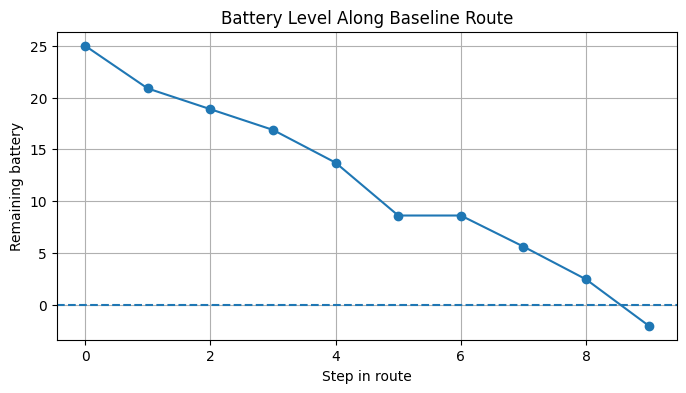

Feasible safe repaired route: True
Safe repaired route: [0, 11, 8, 2, 5, 7, 3, 9, 1, 6, 4, 10, 0]
Battery history (safe): [25.0, np.float64(20.87689437438234), np.float64(18.87689437438234), np.float64(16.87689437438234), np.float64(13.714616714213959), np.float64(8.615597200621174), np.float64(8.615597200621174), np.float64(5.615597200621174), np.float64(2.7871700758749838), 25.0, np.float64(19.900980486407214), np.float64(15.428844531407634), np.float64(13.192776553907844), np.float64(7.807611746773341)]


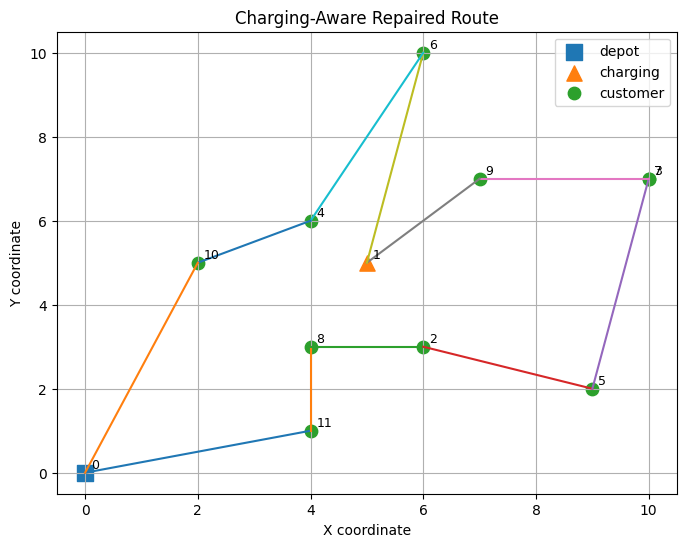

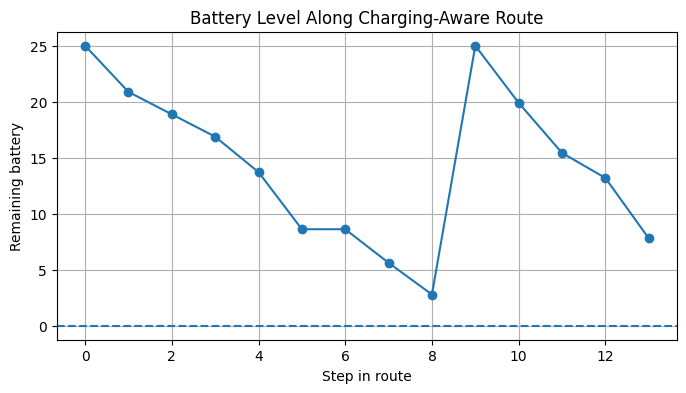

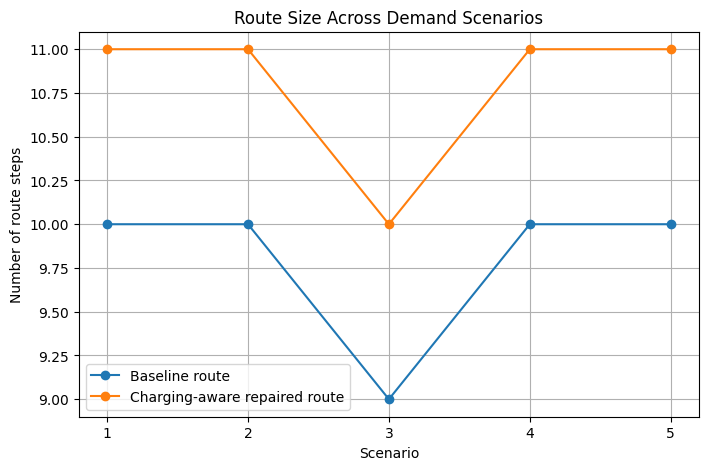

,model,number_of_feasible_scenarios
0,Baseline,0
1,Charging-aware repaired,5


In [ ]:
!pip install ortools pandas matplotlib numpy
from ortools.constraint_solver import pywrapcp, routing_enums_pb2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

depot = {"id": 0, "type": "depot", "x": 0, "y": 0}
charging_station = {"id": 1, "type": "charging", "x": 5, "y": 5}

n_customers = 10
customer_points = []

for i in range(n_customers):
    point = {
        "id": i + 2,
        "type": "customer",
        "x": np.random.randint(0, 11),
        "y": np.random.randint(0, 11),
    }
    customer_points.append(point)

points = [depot, charging_station] + customer_points
df_points = pd.DataFrame(points)
df_points

plt.figure(figsize=(8, 6))

for point_type, marker, size in [
    ("depot", "s", 120),
    ("charging", "^", 120),
    ("customer", "o", 80),
]:
    subset = df_points[df_points["type"] == point_type]
    plt.scatter(subset["x"], subset["y"], label=point_type, marker=marker, s=size)

for _, row in df_points.iterrows():
    plt.text(row["x"] + 0.1, row["y"] + 0.1, str(row["id"]), fontsize=9)

plt.title("Synthetic Demand-Responsive Mobility Network")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.grid(True)
plt.show()

def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def get_coords_by_id(node_id):
    row = df_points[df_points["id"] == node_id].iloc[0]
    return row["x"], row["y"]

def distance_by_id(node_a, node_b):
    x1, y1 = get_coords_by_id(node_a)
    x2, y2 = get_coords_by_id(node_b)
    return euclidean_distance(x1, y1, x2, y2)

battery_capacity = 25.0
energy_per_distance = 1.0
depot_id = 0
charging_id = 1

print("Battery capacity:", battery_capacity)
print("Energy per unit distance:", energy_per_distance)

df_baseline = df_points[df_points["type"] != "charging"].reset_index(drop=True)
df_baseline
n_baseline = len(df_baseline)
distance_matrix_baseline = np.zeros((n_baseline, n_baseline))

for i in range(n_baseline):
    for j in range(n_baseline):
        x1, y1 = df_baseline.loc[i, ["x", "y"]]
        x2, y2 = df_baseline.loc[j, ["x", "y"]]
        distance_matrix_baseline[i, j] = euclidean_distance(x1, y1, x2, y2)

distance_matrix_baseline_int = (distance_matrix_baseline * 100).astype(int)
num_locations = len(distance_matrix_baseline_int)
num_vehicles = 1
depot_index = 0

manager = pywrapcp.RoutingIndexManager(num_locations, num_vehicles, depot_index)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return distance_matrix_baseline_int[from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

solution = routing.SolveWithParameters(search_parameters)

def get_route(solution, routing, manager):
    index = routing.Start(0)
    route = []

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route.append(node)
        index = solution.Value(routing.NextVar(index))

    route.append(manager.IndexToNode(index))
    return route

baseline_route_small = get_route(solution, routing, manager)
baseline_original_ids = df_baseline.loc[baseline_route_small, "id"].tolist()

print("Baseline route (reindexed):", baseline_route_small)
print("Baseline route (original node IDs):", baseline_original_ids)

plt.figure(figsize=(8, 6))

for point_type, marker, size in [
    ("depot", "s", 120),
    ("charging", "^", 120),
    ("customer", "o", 80),
]:
    subset = df_points[df_points["type"] == point_type]
    plt.scatter(subset["x"], subset["y"], label=point_type, marker=marker, s=size)

for _, row in df_points.iterrows():
    plt.text(row["x"] + 0.1, row["y"] + 0.1, str(row["id"]), fontsize=9)

for i in range(len(baseline_original_ids) - 1):
    from_node = baseline_original_ids[i]
    to_node = baseline_original_ids[i + 1]

    x1, y1 = get_coords_by_id(from_node)
    x2, y2 = get_coords_by_id(to_node)

    plt.plot([x1, x2], [y1, y2], "-")

plt.title("Baseline Routing (Depot + Customers Only)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.grid(True)
plt.show()

baseline_battery = battery_capacity
baseline_battery_history = [baseline_battery]
baseline_feasible = True

for i in range(len(baseline_original_ids) - 1):
    from_node = baseline_original_ids[i]
    to_node = baseline_original_ids[i + 1]

    energy_used = distance_by_id(from_node, to_node) * energy_per_distance
    baseline_battery -= energy_used
    baseline_battery_history.append(baseline_battery)

    if baseline_battery < 0:
        baseline_feasible = False
        print(f"Battery depleted between {from_node} -> {to_node}")
        break

print("Baseline EV-feasible route:", baseline_feasible)
print("Baseline battery levels:", baseline_battery_history)
plt.figure(figsize=(8, 4))
plt.plot(baseline_battery_history, marker='o')
plt.axhline(0, linestyle='--')

plt.title("Battery Level Along Baseline Route")
plt.xlabel("Step in route")
plt.ylabel("Remaining battery")
plt.grid(True)
plt.show()

def min_energy_to_safe_point(node_id):
    dist_to_depot = distance_by_id(node_id, depot_id)
    dist_to_charging = distance_by_id(node_id, charging_id)
    return min(dist_to_depot, dist_to_charging) * energy_per_distance

repaired_route_safe = [baseline_original_ids[0]]
battery_safe = battery_capacity
battery_history_safe = [battery_safe]
feasible_safe = True

for i in range(len(baseline_original_ids) - 1):
    current_node = repaired_route_safe[-1]
    next_node = baseline_original_ids[i + 1]

    energy_to_next = distance_by_id(current_node, next_node) * energy_per_distance
    reserve_after_next = min_energy_to_safe_point(next_node)

    if battery_safe < energy_to_next + reserve_after_next:
        energy_to_charging = distance_by_id(current_node, charging_id) * energy_per_distance

        if current_node != charging_id:
            if battery_safe < energy_to_charging:
                feasible_safe = False
                print(f"Cannot safely reach charging station from node {current_node}")
                break

            battery_safe -= energy_to_charging
            repaired_route_safe.append(charging_id)
            battery_history_safe.append(battery_safe)

        battery_safe = battery_capacity
        battery_history_safe.append(battery_safe)

        current_node = charging_id
        energy_to_next = distance_by_id(current_node, next_node) * energy_per_distance
        reserve_after_next = min_energy_to_safe_point(next_node)

        if battery_safe < energy_to_next + reserve_after_next:
            feasible_safe = False
            print(f"Even after charging, node {next_node} is not safely reachable")
            break

    battery_safe -= energy_to_next
    repaired_route_safe.append(next_node)
    battery_history_safe.append(battery_safe)

print("Feasible safe repaired route:", feasible_safe)
print("Safe repaired route:", repaired_route_safe)
print("Battery history (safe):", battery_history_safe)

plt.figure(figsize=(8, 6))

for point_type, marker, size in [
    ("depot", "s", 120),
    ("charging", "^", 120),
    ("customer", "o", 80),
]:
    subset = df_points[df_points["type"] == point_type]
    plt.scatter(subset["x"], subset["y"], label=point_type, marker=marker, s=size)

for _, row in df_points.iterrows():
    plt.text(row["x"] + 0.1, row["y"] + 0.1, str(row["id"]), fontsize=9)

for i in range(len(repaired_route_safe) - 1):
    from_node = repaired_route_safe[i]
    to_node = repaired_route_safe[i + 1]

    x1, y1 = get_coords_by_id(from_node)
    x2, y2 = get_coords_by_id(to_node)

    plt.plot([x1, x2], [y1, y2], "-")

plt.title("Charging-Aware Repaired Route")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(battery_history_safe, marker='o')
plt.axhline(0, linestyle='--')

plt.title("Battery Level Along Charging-Aware Route")
plt.xlabel("Step in route")
plt.ylabel("Remaining battery")
plt.grid(True)
plt.show()

summary_df = pd.DataFrame({
    "model": ["Baseline route", "Charging-aware repaired route"],
    "feasible_under_battery_constraints": [baseline_feasible, feasible_safe],
    "number_of_route_steps": [len(baseline_original_ids), len(repaired_route_safe)]
})

summary_df

np.random.seed(123)

customer_ids = df_points[df_points["type"] == "customer"]["id"].tolist()
n_scenarios = 5
activation_probability = 0.7

scenarios = []

for s in range(n_scenarios):
    active_customers = []
    for cid in customer_ids:
        if np.random.rand() < activation_probability:
            active_customers.append(cid)

    # make sure scenario is not empty
    if len(active_customers) == 0:
        active_customers = [np.random.choice(customer_ids)]

    scenarios.append({
        "scenario_id": s + 1,
        "active_customers": active_customers
    })

scenarios

def solve_baseline_route_for_scenario(active_customer_ids):
    scenario_nodes = [depot_id] + active_customer_ids
    df_scenario = df_points[df_points["id"].isin(scenario_nodes)].copy().reset_index(drop=True)

    n = len(df_scenario)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x1, y1 = df_scenario.loc[i, ["x", "y"]]
            x2, y2 = df_scenario.loc[j, ["x", "y"]]
            distance_matrix[i, j] = euclidean_distance(x1, y1, x2, y2)

    distance_matrix_int = (distance_matrix * 100).astype(int)

    manager = pywrapcp.RoutingIndexManager(n, 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return distance_matrix_int[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

    solution = routing.SolveWithParameters(search_parameters)

    if solution is None:
        return None, None

    index = routing.Start(0)
    route_idx = []

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route_idx.append(node)
        index = solution.Value(routing.NextVar(index))

    route_idx.append(manager.IndexToNode(index))

    original_ids = df_scenario.loc[route_idx, "id"].tolist()
    return original_ids, df_scenario

def evaluate_battery_feasibility(route_ids):
    battery = battery_capacity
    battery_history = [battery]
    feasible = True

    for i in range(len(route_ids) - 1):
        from_node = route_ids[i]
        to_node = route_ids[i + 1]

        energy_used = distance_by_id(from_node, to_node) * energy_per_distance
        battery -= energy_used
        battery_history.append(battery)

        if battery < 0:
            feasible = False
            break

    return feasible, battery_history

def charging_aware_repair(route_ids):
    repaired_route = [route_ids[0]]
    battery = battery_capacity
    battery_history = [battery]
    feasible = True

    for i in range(len(route_ids) - 1):
        current_node = repaired_route[-1]
        next_node = route_ids[i + 1]

        energy_to_next = distance_by_id(current_node, next_node) * energy_per_distance
        reserve_after_next = min_energy_to_safe_point(next_node)

        if battery < energy_to_next + reserve_after_next:
            energy_to_charging = distance_by_id(current_node, charging_id) * energy_per_distance

            if current_node != charging_id:
                if battery < energy_to_charging:
                    feasible = False
                    break

                battery -= energy_to_charging
                repaired_route.append(charging_id)
                battery_history.append(battery)

            battery = battery_capacity
            battery_history.append(battery)

            current_node = charging_id
            energy_to_next = distance_by_id(current_node, next_node) * energy_per_distance
            reserve_after_next = min_energy_to_safe_point(next_node)

            if battery < energy_to_next + reserve_after_next:
                feasible = False
                break

        battery -= energy_to_next
        repaired_route.append(next_node)
        battery_history.append(battery)

    return feasible, repaired_route, battery_history
scenario_results = []

for scenario in scenarios:
    scenario_id = scenario["scenario_id"]
    active_customers = scenario["active_customers"]

    baseline_route_ids, df_scenario = solve_baseline_route_for_scenario(active_customers)

    if baseline_route_ids is None:
        scenario_results.append({
            "scenario_id": scenario_id,
            "n_active_customers": len(active_customers),
            "baseline_feasible": None,
            "repaired_feasible": None,
            "baseline_steps": None,
            "repaired_steps": None
        })
        continue

    baseline_feasible_s, baseline_battery_history_s = evaluate_battery_feasibility(baseline_route_ids)
    repaired_feasible_s, repaired_route_s, repaired_battery_history_s = charging_aware_repair(baseline_route_ids)

    scenario_results.append({
        "scenario_id": scenario_id,
        "n_active_customers": len(active_customers),
        "active_customers": active_customers,
        "baseline_route": baseline_route_ids,
        "baseline_feasible": baseline_feasible_s,
        "baseline_steps": len(baseline_route_ids),
        "repaired_feasible": repaired_feasible_s,
        "repaired_route": repaired_route_s,
        "repaired_steps": len(repaired_route_s)
    })

scenario_results

results_df = pd.DataFrame(scenario_results)
results_df

plot_df = results_df[[
    "scenario_id",
    "baseline_steps",
    "repaired_steps"
]].copy()

plt.figure(figsize=(8, 5))
plt.plot(plot_df["scenario_id"], plot_df["baseline_steps"], marker="o", label="Baseline route")
plt.plot(plot_df["scenario_id"], plot_df["repaired_steps"], marker="o", label="Charging-aware repaired route")

plt.title("Route Size Across Demand Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Number of route steps")
plt.xticks(plot_df["scenario_id"])
plt.legend()
plt.grid(True)
plt.show()

feasibility_summary = pd.DataFrame({
    "model": ["Baseline", "Charging-aware repaired"],
    "number_of_feasible_scenarios": [
        results_df["baseline_feasible"].sum(),
        results_df["repaired_feasible"].sum()
    ]
})

feasibility_summary